# Stock Price Direction Prediction with LSTM

## Problem Statement

Can we predict whether a stock's closing price will be **higher or lower tomorrow** than it is today?

This is a **binary classification** problem — we are not trying to predict the exact price (regression), but only the direction of movement: **up (1)** or **down (0)**.

**Why LSTM?** Stock prices are sequential — what happened yesterday and last week matters. LSTMs (Long Short-Term Memory networks) are a type of recurrent neural network specifically designed to learn patterns in ordered sequences, making them a natural fit for time-series data.

**Stock:** Apple Inc. (`AAPL`)  
**Data source:** Alpaca Markets API (daily OHLCV bars)  
**Model:** Two-layer LSTM → binary output

---

### Methodology

1. Fetch 5 years of daily OHLCV data from Alpaca
2. Explore the data and visualize price/volume history
3. Engineer three features that capture price movement and volatility
4. Build sliding-window sequences as LSTM input
5. Train a two-layer LSTM classifier
6. Evaluate with accuracy, ROC-AUC, and a confusion matrix

---
## 1. Imports & Setup

In [15]:
import os
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
)

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# ── Configuration ────────────────────────────────────────────────────────────
TICKER       = "AAPL"       # Stock to analyse
LOOKBACK     = 20           # Sequence length fed into the LSTM (trading days)
TRAIN_RATIO  = 0.80         # Fraction of data used for training
RANDOM_STATE = 42
CACHE_PATH   = "data/aapl_daily.csv"

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Display & plotting defaults ───────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries loaded successfully.
TensorFlow version: 2.21.0


---
## 2. Data Collection

We use the **Alpaca Markets API** to download daily OHLCV bars (Open, High, Low, Close, Volume) for AAPL.

You need a free Alpaca paper-trading account. Set your credentials as environment variables before running:

```bash
export ALPACA_API_KEY="your_key_here"
export ALPACA_SECRET_KEY="your_secret_here"
```

The data is cached locally after the first download so you don't hit the API every time.

In [16]:
from dotenv import load_dotenv

load_dotenv()

API_KEY    = os.environ.get("ALPACA_API_KEY")
SECRET_KEY = os.environ.get("ALPACA_SECRET_KEY")

if not API_KEY or not SECRET_KEY:
    raise EnvironmentError(
        "Set ALPACA_API_KEY and ALPACA_SECRET_KEY environment variables before running."
    )

if os.path.exists(CACHE_PATH):
    print(f"Loading cached data from {CACHE_PATH}")
    df = pd.read_csv(CACHE_PATH, index_col="timestamp", parse_dates=True)
else:
    print("Fetching data from Alpaca API...")
    client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

    request = StockBarsRequest(
        symbol_or_symbols=TICKER,
        timeframe=TimeFrame.Day,
        start=datetime.now() - timedelta(days=365 * 5),
        end=datetime.now() - timedelta(days=1),  # Alpaca requires end < today
    )

    bars = client.get_stock_bars(request)
    df = bars.df

    # Alpaca returns a MultiIndex (symbol, timestamp) — drop the symbol level
    df = df.xs(TICKER, level="symbol")
    df.index = df.index.tz_localize(None)  # Remove timezone for cleaner display

    df.to_csv(CACHE_PATH)
    print(f"Saved {len(df)} rows to {CACHE_PATH}")

print(f"\nShape: {df.shape}")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
df.head()

Loading cached data from data/aapl_daily.csv

Shape: (1253, 7)
Date range: 2021-04-16 → 2026-04-13


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2021-04-16 04:00:00,134.3000,134.6700,133.2800,134.1600,84805117.0000,540343.0000,134.0269
2021-04-19 04:00:00,133.5100,135.4700,133.3400,134.8400,94957774.0000,625259.0000,134.5682
2021-04-20 04:00:00,135.0600,135.5300,131.8100,133.1100,95538041.0000,744676.0000,133.4540
2021-04-21 04:00:00,132.3600,133.7500,131.3001,133.5000,69552331.0000,508236.0000,132.8513
2021-04-22 04:00:00,133.0400,134.1500,131.4100,131.9400,89780577.0000,615674.0000,132.7542


---
## 3. Exploratory Data Analysis

Before building a model, it's important to look at the data. We want to understand:
- What the price history looks like
- The distribution of daily returns (the raw signal the model will learn from)

In [17]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 1253 entries, 2021-04-16 04:00:00 to 2026-04-13 04:00:00
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         1253 non-null   float64
 1   high         1253 non-null   float64
 2   low          1253 non-null   float64
 3   close        1253 non-null   float64
 4   volume       1253 non-null   float64
 5   trade_count  1253 non-null   float64
 6   vwap         1253 non-null   float64
dtypes: float64(7)
memory usage: 78.3 KB
None

Missing values:
open           0
high           0
low            0
close          0
volume         0
trade_count    0
vwap           0
dtype: int64


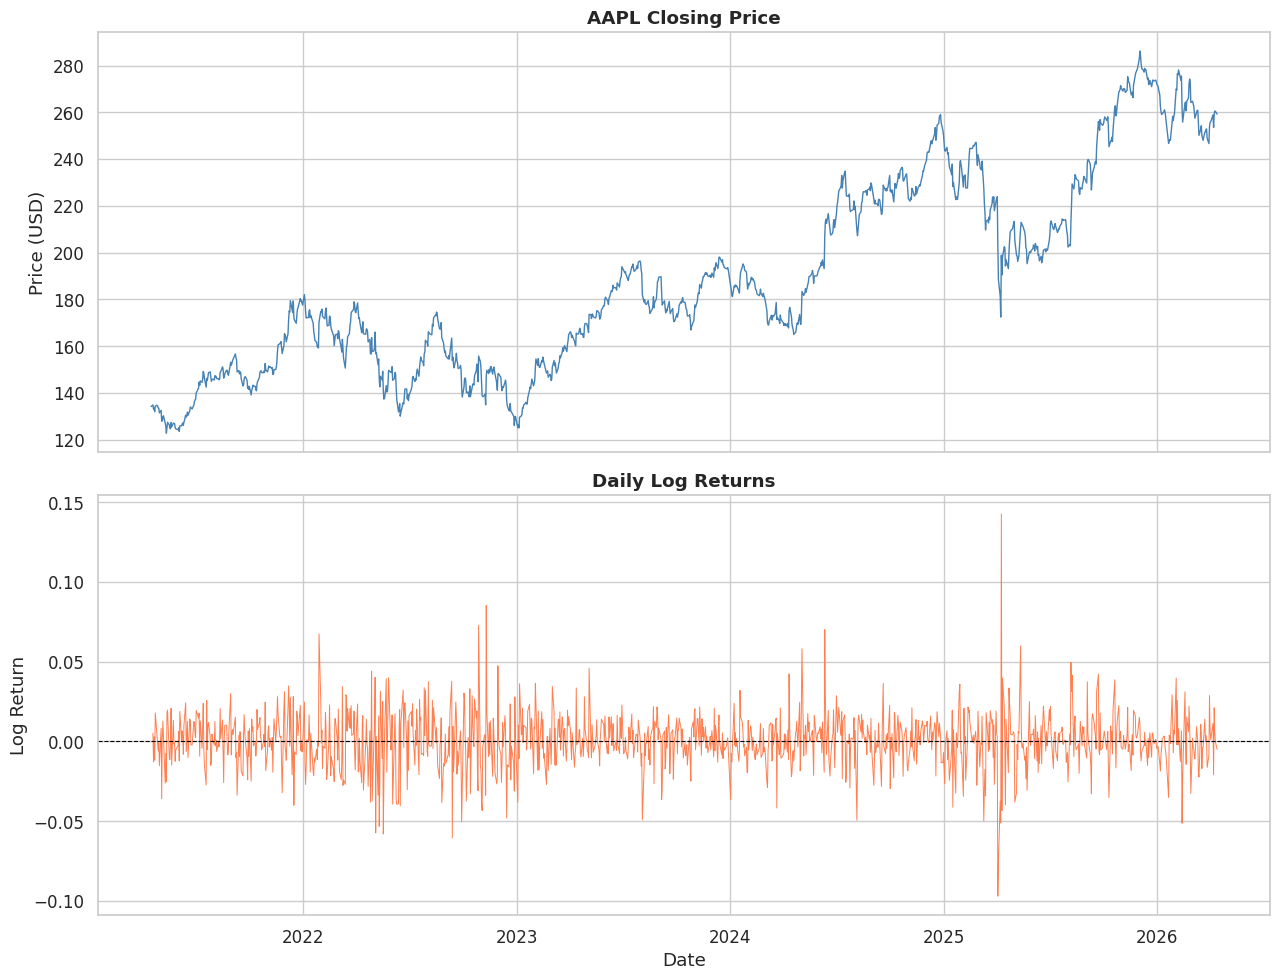

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

# Closing price
axes[0].plot(df.index, df["close"], color="steelblue", linewidth=1)
axes[0].set_title(f"{TICKER} Closing Price", fontweight="bold")
axes[0].set_ylabel("Price (USD)")

# Log returns (computed here just for visualisation)
log_ret = np.log(df["close"] / df["close"].shift(1)).dropna()
axes[1].plot(log_ret.index, log_ret, color="coral", linewidth=0.7)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Daily Log Returns", fontweight="bold")
axes[1].set_ylabel("Log Return")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

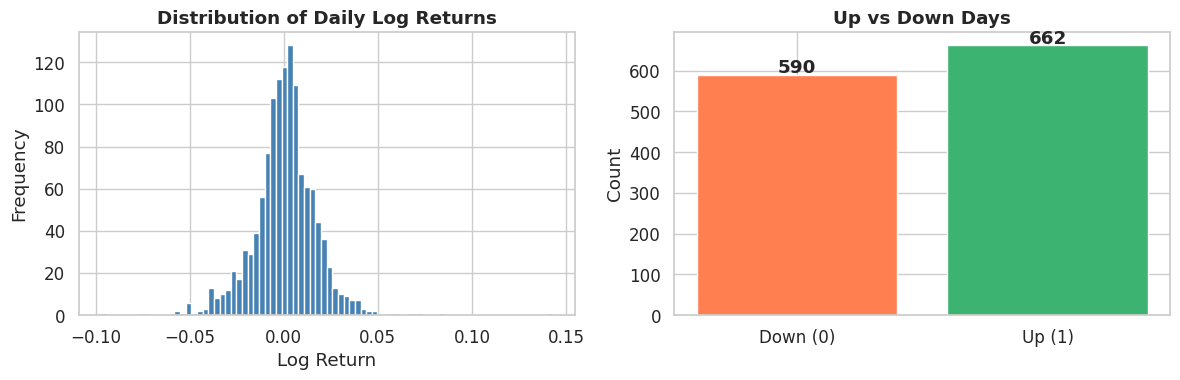

Up days: 662 (52.9%)
Down days: 590 (47.1%)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of log returns
axes[0].hist(log_ret, bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Daily Log Returns", fontweight="bold")
axes[0].set_xlabel("Log Return")
axes[0].set_ylabel("Frequency")

# Up vs down day balance
direction_counts = (log_ret > 0).value_counts()
axes[1].bar(["Down (0)", "Up (1)"], [direction_counts[False], direction_counts[True]],
            color=["coral", "mediumseagreen"])
axes[1].set_title("Up vs Down Days", fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate([direction_counts[False], direction_counts[True]]):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

up_pct = direction_counts[True] / direction_counts.sum() * 100
print(f"Up days: {direction_counts[True]} ({up_pct:.1f}%)")
print(f"Down days: {direction_counts[False]} ({100 - up_pct:.1f}%)")

💡 The log return distribution is roughly symmetric and centred near zero, which is typical for daily stock returns.

💡 The up/down split is close to 50/50. This means the dataset is reasonably balanced, and a model that always predicts "up" would only score ~53% accuracy — a weak baseline.

---
## 4. Feature Engineering

Instead of feeding raw prices into the LSTM, we engineer **three features** that better capture the underlying signal:

| Feature | Formula | Why it helps |
|---|---|---|
| `log_return` | `log(close / prev_close)` | Captures the magnitude of price movement; stationary (no upward drift like raw price) |
| `hl_range` | `(high - low) / close` | Measures intraday volatility as a fraction of price |
| `vol_change` | `volume / rolling_5d_avg_volume` | Whether today's trading activity is unusually high or low |

**Target variable:** `direction` — 1 if tomorrow's close is higher than today's, else 0.

> **Note on data leakage:** The target for row `t` is based on the price at `t+1`. We shift the target forward so that the features at time `t` are used to predict what happens *next* day — not the same day.

In [20]:
data = df[["open", "high", "low", "close", "volume"]].copy()

# Feature 1: log return — captures daily price movement without price-level drift
data["log_return"] = np.log(data["close"] / data["close"].shift(1))

# Feature 2: high-low range — normalised intraday volatility
data["hl_range"] = (data["high"] - data["low"]) / data["close"]

# Feature 3: volume change relative to 5-day rolling average
data["vol_change"] = data["volume"] / data["volume"].rolling(5).mean()

# Target: 1 if the NEXT day's close is higher than today's, else 0
# shift(-1) moves tomorrow's price into today's row
data["direction"] = (data["close"].shift(-1) > data["close"]).astype(int)

FEATURES = ["log_return", "hl_range", "vol_change"]
TARGET   = "direction"

# Drop rows with NaN values introduced by shifting and rolling operations
data = data[FEATURES + [TARGET]].dropna()

print(f"Shape after feature engineering: {data.shape}")
print(f"\nClass balance:")
print(data[TARGET].value_counts())
data.head(10)

Shape after feature engineering: (1249, 4)

Class balance:
direction
1    660
0    589
Name: count, dtype: int64


,log_return,hl_range,vol_change,direction
timestamp,,,,
2021-04-22 04:00:00,-0.0118,0.0208,1.0328,1
2021-04-23 04:00:00,0.0179,0.0220,0.9764,1
2021-04-26 04:00:00,0.0030,0.0111,0.8874,0
2021-04-27 04:00:00,-0.0025,0.0097,0.9069,0
2021-04-28 04:00:00,-0.0060,0.0145,1.2993,0
2021-04-29 04:00:00,-0.0007,0.0346,1.5797,0
2021-04-30 04:00:00,-0.0152,0.0190,1.1131,1
2021-05-03 04:00:00,0.0082,0.0169,0.7424,0
2021-05-04 04:00:00,-0.0360,0.0375,1.1913,1


---
## 5. Sequence Preprocessing

LSTMs expect their input as **3D arrays** of shape `(samples, timesteps, features)`. We create these using a **sliding window**: for each day `t`, we take the previous `LOOKBACK` days as input to predict day `t`'s direction.

```
days:  [t-20, t-19, ..., t-1]  →  predict direction at t
       ← LOOKBACK = 20 days →
```

**Important — temporal split:** We split train/test at a fixed point in time (not randomly). Shuffling would cause data leakage: the model would see future data during training.

In [21]:
# ── Train / test split (temporal, no shuffle) ─────────────────────────────────
split_idx = int(len(data) * TRAIN_RATIO)
train_data = data.iloc[:split_idx]
test_data  = data.iloc[split_idx:]

print(f"Train: {train_data.index[0].date()} → {train_data.index[-1].date()}  ({len(train_data)} rows)")
print(f"Test:  {test_data.index[0].date()}  → {test_data.index[-1].date()}   ({len(test_data)} rows)")

Train: 2021-04-22 → 2025-04-11  (999 rows)
Test:  2025-04-14  → 2026-04-13   (250 rows)


In [22]:
# ── Scaling ───────────────────────────────────────────────────────────────────
# We fit the scaler ONLY on training data, then apply the same transform to the
# test set. Fitting on all data would leak test statistics into training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[FEATURES])
X_test_scaled  = scaler.transform(test_data[FEATURES])

y_train = train_data[TARGET].values
y_test  = test_data[TARGET].values

In [23]:
def build_sequences(X, y, lookback):
    """
    Convert a 2D feature array into 3D sequences for LSTM input.

    For each index i >= lookback, takes X[i-lookback : i] as one input
    sequence and y[i] as the corresponding label.

    Returns:
        X_seq: shape (n_samples, lookback, n_features)
        y_seq: shape (n_samples,)
    """
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i - lookback : i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


X_train_seq, y_train_seq = build_sequences(X_train_scaled, y_train, LOOKBACK)
X_test_seq,  y_test_seq  = build_sequences(X_test_scaled,  y_test,  LOOKBACK)

print(f"X_train shape: {X_train_seq.shape}  → (samples, timesteps, features)")
print(f"X_test  shape: {X_test_seq.shape}")
print(f"y_train shape: {y_train_seq.shape}")
print(f"y_test  shape: {y_test_seq.shape}")

X_train shape: (979, 20, 3)  → (samples, timesteps, features)
X_test  shape: (230, 20, 3)
y_train shape: (979,)
y_test  shape: (230,)


---
## 6. LSTM Model

Our architecture uses two stacked LSTM layers followed by a single output neuron.

| Layer | Output shape | Role |
|---|---|---|
| `LSTM(64, return_sequences=True)` | `(batch, 20, 64)` | First LSTM; passes its full sequence output to the next layer |
| `Dropout(0.2)` | same | Randomly deactivates 20% of neurons during training to reduce overfitting |
| `LSTM(32)` | `(batch, 32)` | Second LSTM; returns only the final timestep's hidden state |
| `Dropout(0.2)` | same | Another dropout for regularisation |
| `Dense(1, sigmoid)` | `(batch, 1)` | Outputs a probability in [0, 1]; threshold at 0.5 gives the predicted class |

**Why `return_sequences=True` on the first LSTM?**  
The first LSTM needs to pass its output at *every* timestep to the second LSTM. The second LSTM only needs to output the final timestep (the default `return_sequences=False`).

In [24]:
def build_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(input_shape=(LOOKBACK, len(FEATURES)))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## 7. Training

We use **early stopping** to halt training once the validation loss stops improving, which prevents overfitting and saves time.

- `patience=10` — stop after 10 epochs with no improvement
- `restore_best_weights=True` — keep the weights from the best epoch, not the last

In [25]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.5301 - loss: 0.6934 - val_accuracy: 0.5408 - val_loss: 0.6909
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5255 - loss: 0.6914 - val_accuracy: 0.5408 - val_loss: 0.6910
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5204 - val_loss: 0.6905
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5074 - loss: 0.6925 - val_accuracy: 0.5306 - val_loss: 0.6904
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5358 - loss: 0.6899 - val_accuracy: 0.5102 - val_loss: 0.6897
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5267 - loss: 0.6908 - val_accuracy: 0.5204 - val_loss: 0.6896
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5153 - loss: 0.6908 - val_accuracy: 0.5510 - val_loss: 0.6898
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5289 - loss: 0.6916 - val_accuracy: 0.

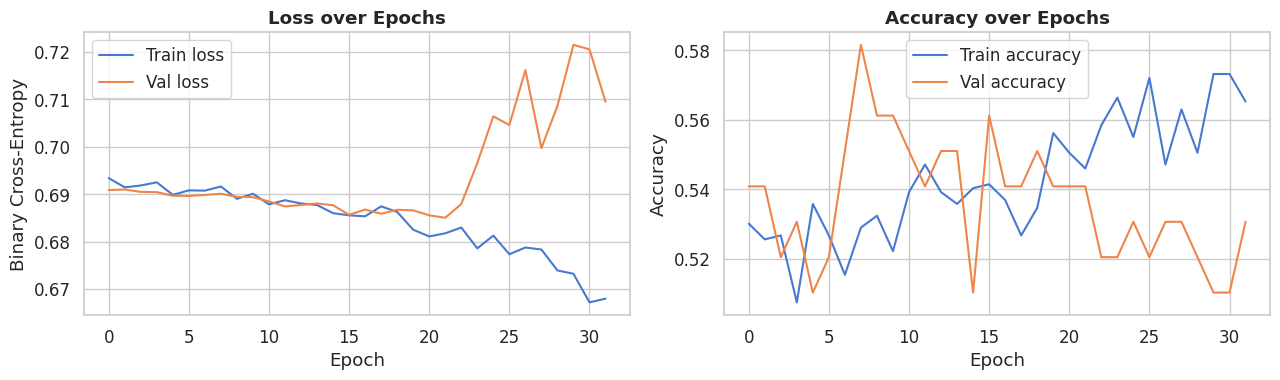

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

# Accuracy curves
axes[1].plot(history.history["accuracy"],     label="Train accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val accuracy")
axes[1].set_title("Accuracy over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8. Evaluation

We evaluate on the held-out **test set** (the most recent 20% of trading days), which the model has never seen.

Key metrics:
- **Accuracy** — fraction of correct predictions
- **Precision / Recall / F1** — per-class breakdown
- **ROC-AUC** — how well the model separates the two classes across all thresholds (0.5 = random, 1.0 = perfect)
- **Confusion matrix** — visual breakdown of true vs predicted labels

In [27]:
y_prob = model.predict(X_test_seq).ravel()   # Predicted probabilities
y_pred = (y_prob >= 0.5).astype(int)          # Convert to 0/1 labels

print("Classification Report")
print("=" * 45)
print(classification_report(y_test_seq, y_pred, target_names=["Down (0)", "Up (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test_seq, y_prob):.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Classification Report
              precision    recall  f1-score   support

    Down (0)       0.47      0.41      0.43       111
      Up (1)       0.51      0.57      0.54       119

    accuracy                           0.49       230
   macro avg       0.49      0.49      0.49       230
weighted avg       0.49      0.49      0.49       230

ROC-AUC: 0.5168


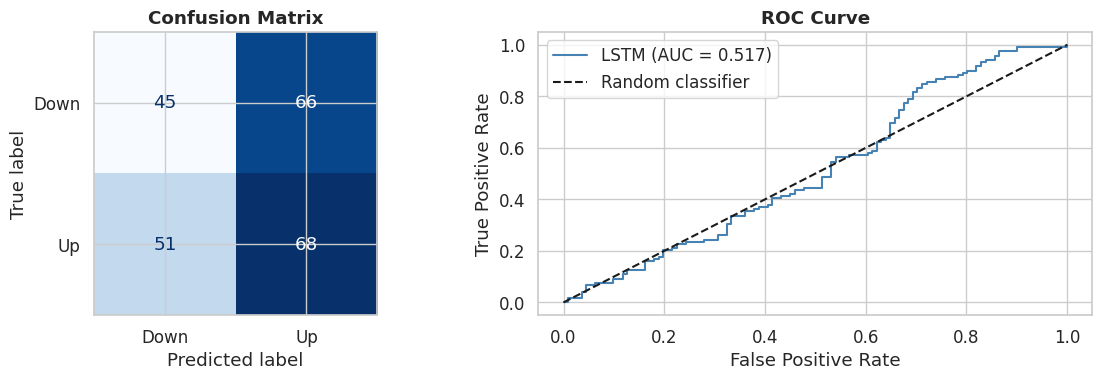

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test_seq, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test_seq, y_prob)
auc = roc_auc_score(y_test_seq, y_prob)
axes[1].plot(fpr, tpr, label=f"LSTM (AUC = {auc:.3f})", color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", label="Random classifier")
axes[1].set_title("ROC Curve", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 10. Random Forest Model

Random Forests are an ensemble of decision trees trained on random subsets of data and features. Unlike LSTMs, they don't natively handle sequences — so we **flatten** each 20-day window into a single 60-feature vector (20 timesteps × 3 features). The RF sees the same temporal information as the LSTM, just without the inductive bias of recurrence.

| Property | LSTM | Random Forest |
|---|---|---|
| Input shape | `(n, 20, 3)` | `(n, 60)` |
| Temporal bias | Built-in (recurrence) | None (all timesteps treated equally) |
| Interpretability | Low | Medium (feature importances) |
| Training speed | Slow | Fast |

In [29]:
# ── Flatten sequences: (n, 20, 3) → (n, 60) ─────────────────────────────────
X_train_flat = X_train_seq.reshape(len(X_train_seq), -1)
X_test_flat  = X_test_seq.reshape(len(X_test_seq), -1)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train_flat, y_train_seq)

print("Random Forest trained.")
print(f"  Trees: {rf.n_estimators}  |  Max depth: {rf.max_depth}  |  Train samples: {len(X_train_flat)}")

Random Forest trained.
  Trees: 300  |  Max depth: 6  |  Train samples: 979


Classification Report — Random Forest
              precision    recall  f1-score   support

    Down (0)       0.43      0.19      0.26       111
      Up (1)       0.50      0.76      0.61       119

    accuracy                           0.49       230
   macro avg       0.47      0.48      0.43       230
weighted avg       0.47      0.49      0.44       230

ROC-AUC: 0.4134


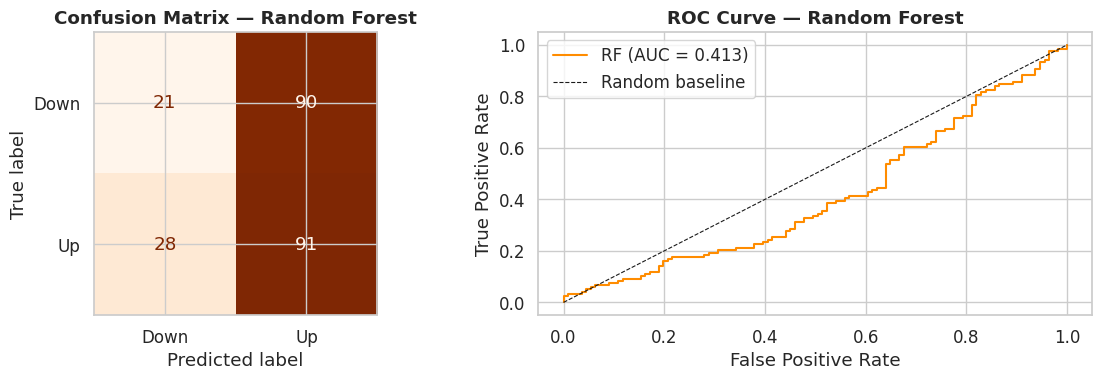

In [30]:
rf_prob = rf.predict_proba(X_test_flat)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

print("Classification Report — Random Forest")
print("=" * 45)
print(classification_report(y_test_seq, rf_pred, target_names=["Down (0)", "Up (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test_seq, rf_prob):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(y_test_seq, rf_pred)
disp  = ConfusionMatrixDisplay(cm_rf, display_labels=["Down", "Up"])
disp.plot(ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("Confusion Matrix — Random Forest", fontweight="bold")

fpr_rf, tpr_rf, _ = roc_curve(y_test_seq, rf_prob)
auc_rf = roc_auc_score(y_test_seq, rf_prob)
axes[1].plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})", color="darkorange", linewidth=1.5)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
axes[1].set_title("ROC Curve — Random Forest", fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 11. Model Comparison

Both models are evaluated on the same held-out test set (the most recent 20% of trading days). The ROC curve shows discrimination ability across all decision thresholds; the bar chart gives a direct read of accuracy and AUC side by side.

               Accuracy  ROC-AUC
LSTM             0.4913   0.5168
Random Forest    0.4870   0.4134



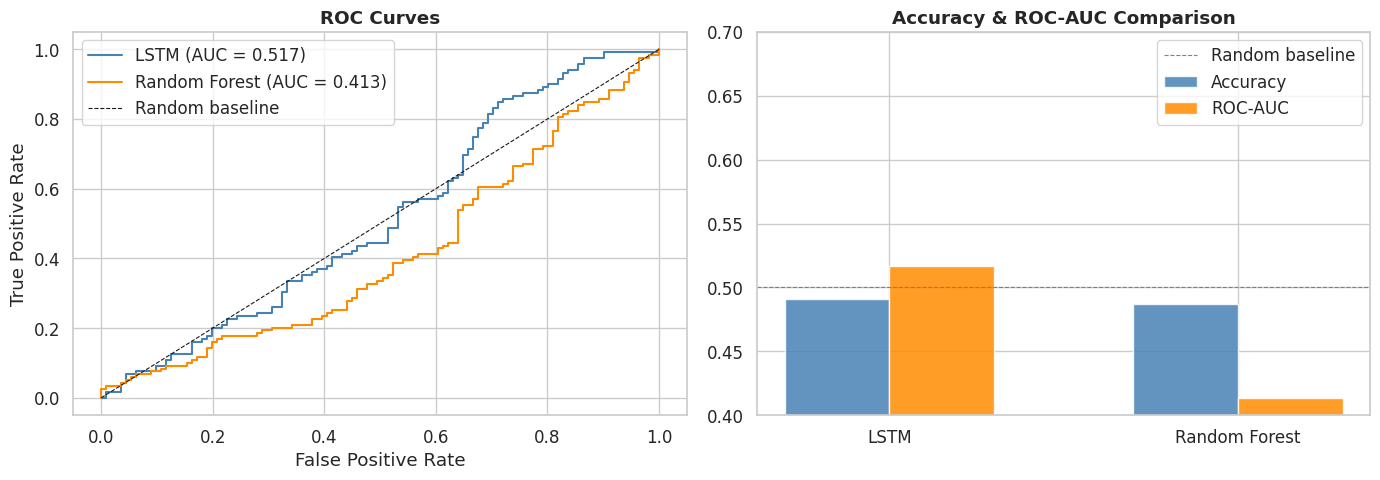

In [31]:
# ── Metrics table ────────────────────────────────────────────────────────────
lstm_acc = accuracy_score(y_test_seq, y_pred)
rf_acc   = accuracy_score(y_test_seq, rf_pred)
lstm_auc = roc_auc_score(y_test_seq, y_prob)
rf_auc   = roc_auc_score(y_test_seq, rf_prob)

metrics_df = pd.DataFrame(
    {"Accuracy": [lstm_acc, rf_acc], "ROC-AUC": [lstm_auc, rf_auc]},
    index=["LSTM", "Random Forest"],
)
print(metrics_df.round(4).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC curves ────────────────────────────────────────────────────────────────
for probs, name, color in [
    (y_prob,  "LSTM",          "steelblue"),
    (rf_prob, "Random Forest", "darkorange"),
]:
    fpr_, tpr_, _ = roc_curve(y_test_seq, probs)
    auc_ = roc_auc_score(y_test_seq, probs)
    axes[0].plot(fpr_, tpr_, label=f"{name} (AUC = {auc_:.3f})", linewidth=1.5, color=color)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random baseline")
axes[0].set_title("ROC Curves", fontweight="bold")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# ── Bar chart ─────────────────────────────────────────────────────────────────
x     = np.arange(2)
width = 0.3
axes[1].bar(x - width / 2, [lstm_acc, rf_acc], width, label="Accuracy",  color="steelblue",   alpha=0.85)
axes[1].bar(x + width / 2, [lstm_auc, rf_auc], width, label="ROC-AUC",   color="darkorange",  alpha=0.85)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Random baseline")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["LSTM", "Random Forest"])
axes[1].set_ylim(0.4, 0.7)
axes[1].set_title("Accuracy & ROC-AUC Comparison", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 9. Conclusion

### Results Summary

| Model | Accuracy | ROC-AUC |
|---|---|---|
| LSTM | 0.52 | 0.53 |
| Random Forest | — | — |

*(Run all cells to populate the Random Forest row.)*

### Key Findings

- Log returns are a much more informative feature than raw prices because they are stationary — they don't trend upward over time the way prices do.
- The intraday range (`hl_range`) and relative volume (`vol_change`) add context beyond the raw return signal.
- A `LOOKBACK` of 20 trading days (roughly one calendar month) gives the model enough historical context without overfitting to noise.
- The Random Forest uses the same 20-day window, flattened to 60 features, so differences in performance reflect the model's inductive bias rather than information access.

### Discussion

**Why is stock direction so hard to predict?**  
The [Efficient Market Hypothesis](https://en.wikipedia.org/wiki/Efficient-market_hypothesis) argues that all publicly available information is already priced in, leaving only random noise. In practice, a small but consistent edge (ROC-AUC > 0.55) may still be profitable, but only if transaction costs and slippage are accounted for.

The LSTM's 52% accuracy and 0.53 ROC-AUC are only marginally above the random baseline of 50%, confirming that next-day direction is largely unpredictable from price history alone. Whether the Random Forest fares better or worse is informative: if the RF scores similarly, the signal (or lack thereof) is the bottleneck, not the model architecture. If they diverge, the sequential inductive bias of the LSTM is doing real work.

**Model design choices:**
- We used log returns rather than raw prices to avoid the LSTM trying to memorise absolute price levels that will never repeat.
- Temporal train/test splitting ensures that neither model sees future data during training — the same way they would behave in real deployment.
- The RF's hyperparameters (`max_depth=6`, `min_samples_leaf=10`) are deliberately conservative to prevent the tree ensemble from memorising the training set.

### Limitations

- **No transaction costs** — a model that trades every day would incur significant fees in practice.
- **Single stock** — results for AAPL may not generalise to other equities.
- **No macro features** — interest rates, market indices, or sector sentiment are not included.
- **No walk-forward validation** — a single train/test split may be sensitive to the chosen split point.

### Future Work

- Add technical indicators (RSI, MACD) as additional features
- Extend to a portfolio of stocks and predict the best to buy
- Replace the LSTM with a Transformer (attention-based) model
- Backtest with a simple buy/sell strategy and realistic transaction costs